# Notebook 05 Batch Inference, Evaluasi Otomatis, dan Plot

Notebook ini menjalankan batch inference untuk ground truth, menghitung metrik retrieval dan kualitas jawaban, menyimpan tabel evaluasi, membuat review kegagalan, dan menghasilkan plot otomatis.

In [1]:
# Jalankan bila package belum ada
!pip install chromadb rank_bm25 sentence-transformers transformers accelerate bitsandbytes pandas numpy matplotlib scikit-learn openpyxl tabulate tqdm

In [2]:
import os, re, json, time, pickle, math
from pathlib import Path
from typing import Dict, List, Any

import numpy as np
import pandas as pd
import torch
import chromadb
import matplotlib.pyplot as plt
from rank_bm25 import BM25Okapi
from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity
from tqdm.auto import tqdm

DATA_PATH = Path("../data/processed_chunks_ringan_pasal_chroma_ready.json")
CHROMA_DB_DIR = Path("../data/chroma_db")
COLLECTION_NAME = "hukum_ketenagakerjaan"
BM25_PATH = Path("../data/bm25_index.pkl")
GROUND_TRUTH_CSV = Path("../data/ground_truth_eval_20.csv")
OUTPUT_DIR = Path("../data/eval_outputs")
PLOT_DIR = OUTPUT_DIR / "plots"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
PLOT_DIR.mkdir(parents=True, exist_ok=True)

EMBEDDING_MODEL_NAME = "intfloat/multilingual-e5-base"
RERANKER_MODEL_NAME = "BAAI/bge-reranker-v2-m3"
SEMANTIC_MODEL = "sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2"
USE_RERANKER = True
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

print("device", DEVICE)
print("ground truth", GROUND_TRUTH_CSV.resolve())
print("output", OUTPUT_DIR.resolve())

device cuda
ground truth /workspace/RAG-LEGAL-LAW-INDONESIA/data/ground_truth_eval_20.csv
output /workspace/RAG-LEGAL-LAW-INDONESIA/data/eval_outputs


In [3]:
def tokenize_for_bm25(text: str) -> List[str]:
    return re.findall(r"[a-zA-Z0-9_]+|[\u00C0-\u024F\u1E00-\u1EFF]+|[\w]+", str(text).lower())


def normalize_text(text: str) -> str:
    text = re.sub(r"\s+", " ", str(text)).strip()
    return text


def load_chunks(path: Path) -> List[Dict[str, Any]]:
    if not path.exists():
        raise FileNotFoundError(f"Chunk tidak ditemukan: {path}. Jalankan notebook 01 untuk embedding dan indexing dulu.")
    chunks = json.loads(path.read_text(encoding="utf-8"))
    for i, c in enumerate(chunks[:10]):
        for k in ["id", "text", "display_text", "embedding_text", "citation_text", "metadata"]:
            if k not in c:
                raise ValueError(f"Schema chunk belum sesuai. Field hilang: {k} pada index {i}")
    return chunks

chunks = load_chunks(DATA_PATH)
id_to_chunk = {c["id"]: c for c in chunks}
print("chunks", len(chunks))

embedding_model = SentenceTransformer(EMBEDDING_MODEL_NAME, device=DEVICE)
client = chromadb.PersistentClient(path=str(CHROMA_DB_DIR))
collection = client.get_collection(COLLECTION_NAME)
print("chroma count", collection.count())
if collection.count() != len(chunks):
    raise ValueError(f"Chroma count {collection.count()} tidak sama dengan chunks {len(chunks)}. Jalankan notebook 01 dulu.")

bm25 = None
bm25_ids = []
if BM25_PATH.exists():
    with BM25_PATH.open("rb") as f:
        payload = pickle.load(f)
    bm25 = payload.get("bm25")
    bm25_ids = payload.get("ids", [])
    print("bm25", len(bm25_ids))
else:
    print("BM25 tidak ditemukan. Dense retrieval tetap berjalan.")

chunks 7363


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

chroma count 7363
bm25 7363


In [4]:
QUERY_EXPANSIONS = [
    {"triggers": ["pkwt", "kontrak"], "expansion": "perjanjian kerja waktu tertentu kompensasi jangka waktu perpanjangan masa percobaan harian menjadi PKWTT"},
    {"triggers": ["alih daya", "outsourcing"], "expansion": "perusahaan alih daya badan hukum perizinan berusaha perlindungan upah kesejahteraan syarat kerja perselisihan"},
    {"triggers": ["phk", "pesangon", "pengunduran", "mendesak", "surat peringatan"], "expansion": "pemutusan hubungan kerja uang pesangon uang penghargaan masa kerja uang penggantian hak uang pisah pelanggaran bersifat mendesak"},
    {"triggers": ["upah", "pengupahan", "minimum", "tunjangan", "struktur"], "expansion": "upah minimum struktur skala upah upah pokok tunjangan tetap diskriminasi pekerjaan yang sama nilainya"},
    {"triggers": ["lembur", "waktu kerja", "jam kerja"], "expansion": "waktu kerja 7 jam 8 jam 40 jam seminggu perintah kerja lembur persetujuan pekerja"},
]


def expand_query(query: str) -> str:
    q = query.lower()
    additions = []
    for rule in QUERY_EXPANSIONS:
        if any(t in q for t in rule["triggers"]):
            additions.append(rule["expansion"])
    return normalize_text(query + " " + " ".join(additions))


def dense_search(query: str, fetch_k: int = 40) -> List[Dict[str, Any]]:
    q_emb = embedding_model.encode(["query: " + query], convert_to_numpy=True, normalize_embeddings=True, show_progress_bar=False)[0].tolist()
    res = collection.query(query_embeddings=[q_emb], n_results=fetch_k, include=["documents", "metadatas", "distances"])
    hits = []
    for doc_id, doc, meta, dist in zip(res["ids"][0], res["documents"][0], res["metadatas"][0], res["distances"][0]):
        hits.append({"id": doc_id, "text": doc, "metadata": meta or {}, "dense_distance": float(dist), "source": "dense"})
    return hits


def bm25_search(query: str, fetch_k: int = 40) -> List[Dict[str, Any]]:
    if bm25 is None or not bm25_ids:
        return []
    scores = bm25.get_scores(tokenize_for_bm25(query))
    order = np.argsort(scores)[::-1][:fetch_k]
    ids = [bm25_ids[i] for i in order if scores[i] > 0]
    if not ids:
        return []
    got = collection.get(ids=ids, include=["documents", "metadatas"])
    lookup = {doc_id: (doc, meta) for doc_id, doc, meta in zip(got["ids"], got["documents"], got["metadatas"])}
    hits = []
    for i in order:
        doc_id = bm25_ids[i]
        if scores[i] <= 0 or doc_id not in lookup:
            continue
        doc, meta = lookup[doc_id]
        hits.append({"id": doc_id, "text": doc, "metadata": meta or {}, "bm25_score": float(scores[i]), "source": "bm25"})
    return hits


def rrf_fuse(result_sets: List[List[Dict[str, Any]]], weights=None, rrf_k: int = 60) -> List[Dict[str, Any]]:
    weights = weights or [1.0] * len(result_sets)
    fused = {}
    for hits, weight in zip(result_sets, weights):
        for rank, hit in enumerate(hits, 1):
            item = fused.setdefault(hit["id"], {"score": 0.0, "hit": hit})
            item["score"] += weight / (rrf_k + rank)
            item["hit"].update({k: v for k, v in hit.items() if k not in item["hit"]})
    out = []
    for item in sorted(fused.values(), key=lambda x: x["score"], reverse=True):
        hit = item["hit"]
        hit["rrf_score"] = float(item["score"])
        out.append(hit)
    return out

reranker = None
if USE_RERANKER:
    from sentence_transformers import CrossEncoder
    reranker = CrossEncoder(RERANKER_MODEL_NAME, device=DEVICE)
    print("reranker aktif", RERANKER_MODEL_NAME)


def rerank_documents(query: str, docs: List[Dict[str, Any]], k: int = 8) -> List[Dict[str, Any]]:
    if reranker is None or not docs:
        return docs[:k]
    scores = reranker.predict([(query, d["text"]) for d in docs])
    for d, s in zip(docs, scores):
        d["rerank_score"] = float(s)
    return sorted(docs, key=lambda x: x.get("rerank_score", 0.0), reverse=True)[:k]


def dedupe_legal_hits(docs: List[Dict[str, Any]]) -> List[Dict[str, Any]]:
    seen, out = set(), []
    for d in docs:
        m = d.get("metadata", {})
        key = (m.get("source_file", ""), m.get("pasal_id", ""), m.get("chunk_index", ""), d.get("id", ""))
        if key in seen:
            continue
        seen.add(key)
        out.append(d)
    return out


def retrieve_documents(query: str, fetch_k: int = 40, final_k: int = 8) -> List[Dict[str, Any]]:
    qx = expand_query(query)
    fused = rrf_fuse([dense_search(qx, fetch_k), bm25_search(qx, fetch_k)], weights=[1.0, 0.8])
    fused = dedupe_legal_hits(fused)
    return rerank_documents(query, fused, k=final_k)


def build_reference(meta: Dict[str, Any]) -> str:
    citation = meta.get("citation_text") or meta.get("citation") or ""
    source = meta.get("source_file") or meta.get("file_name") or ""
    pasal = meta.get("pasal_id") or meta.get("article") or ""
    parts = [citation, source, pasal]
    return " | ".join([str(p) for p in parts if str(p).strip()])


def assemble_context(docs: List[Dict[str, Any]], max_docs: int = 6) -> str:
    blocks = []
    for i, d in enumerate(docs[:max_docs], 1):
        meta = d.get("metadata", {})
        ref = build_reference(meta) or f"Dokumen {i}"
        text = normalize_text(d.get("text", ""))[:2500]
        blocks.append(f"[R{i}] {ref}\n{text}")
    return "\n\n".join(blocks)

Loading weights:   0%|          | 0/393 [00:00<?, ?it/s]

reranker aktif BAAI/bge-reranker-v2-m3


In [5]:
from transformers import AutoModelForCausalLM, AutoTokenizer, BitsAndBytesConfig

MODEL_ID = os.getenv("RAG_LLM_MODEL_ID", "Qwen/Qwen3.5-9B")
MAX_NEW_TOKENS = int(os.getenv("MAX_NEW_TOKENS", "700"))
USE_4BIT = os.getenv("USE_4BIT", "1") == "1" and torch.cuda.is_available()

quantization_config = None
if USE_4BIT:
    quantization_config = BitsAndBytesConfig(
        load_in_4bit=True,
        bnb_4bit_use_double_quant=True,
        bnb_4bit_quant_type="nf4",
        bnb_4bit_compute_dtype=torch.float16,
    )

tokenizer = AutoTokenizer.from_pretrained(MODEL_ID, trust_remote_code=True)
model = AutoModelForCausalLM.from_pretrained(
    MODEL_ID,
    device_map="auto",
    torch_dtype=torch.float16 if torch.cuda.is_available() else torch.float32,
    quantization_config=quantization_config,
    trust_remote_code=True,
)
model.eval()
print("model ready", MODEL_ID)

[transformers] `torch_dtype` is deprecated! Use `dtype` instead!


Fetching 4 files:   0%|          | 0/4 [00:00<?, ?it/s]

[transformers] The fast path is not available because one of the required library is not installed. Falling back to torch implementation. To install follow https://github.com/fla-org/flash-linear-attention#installation and https://github.com/Dao-AILab/causal-conv1d


Loading weights:   0%|          | 0/427 [00:00<?, ?it/s]

/venv/main/lib/python3.12/site-packages/bitsandbytes/backends/cuda/ops.py:213: FutureWarning: _check_is_size will be removed in a future PyTorch release along with guard_size_oblivious.     Use _check(i >= 0) instead.
  torch._check_is_size(blocksize)


model ready Qwen/Qwen3.5-9B


In [6]:
def strip_thinking(text: str) -> str:
    text = re.sub(r"<think>[\s\S]*?</think>", "", text, flags=re.IGNORECASE)
    text = re.sub(r"^\s*(analysis|reasoning)\s*:\s*", "", text, flags=re.IGNORECASE)
    return text.strip()


def apply_chat_template_no_thinking(messages: List[Dict[str, str]]) -> str:
    if hasattr(tokenizer, "apply_chat_template"):
        try:
            return tokenizer.apply_chat_template(messages, tokenize=False, add_generation_prompt=True, enable_thinking=False)
        except TypeError:
            return tokenizer.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)
    return "\n".join([f"{m['role']}: {m['content']}" for m in messages]) + "\nassistant:"


def generate_chat_text(messages: List[Dict[str, str]], max_new_tokens: int = MAX_NEW_TOKENS) -> str:
    prompt = apply_chat_template_no_thinking(messages)
    inputs = tokenizer(prompt, return_tensors="pt").to(model.device)
    with torch.no_grad():
        output_ids = model.generate(
            **inputs,
            max_new_tokens=max_new_tokens,
            do_sample=False,
            temperature=None,
            top_p=None,
            eos_token_id=tokenizer.eos_token_id,
            pad_token_id=tokenizer.eos_token_id,
        )
    new_ids = output_ids[0][inputs["input_ids"].shape[-1]:]
    text = tokenizer.decode(new_ids, skip_special_tokens=True)
    return strip_thinking(text)

SYSTEM_PROMPT = """Kamu adalah asisten hukum ketenagakerjaan Indonesia. Jawab hanya berdasarkan REFERENSI yang diberikan. Jika referensi tidak cukup, katakan bahwa referensi yang tersedia belum cukup. Jangan tampilkan proses berpikir. Sebutkan dasar hukum natural seperti PP Nomor 35 Tahun 2021 Pasal 52 ayat 2. Jawaban harus ringkas, jelas, dan langsung menjawab kasus."""


def generate_answer(question: str, k: int = 8, max_context_docs: int = 6) -> Dict[str, Any]:
    t0 = time.time()
    docs = retrieve_documents(question, final_k=k)
    context = assemble_context(docs, max_docs=max_context_docs)
    user_prompt = f"REFERENSI:\n{context}\n\nPERTANYAAN:\n{question}\n\nJAWABAN:"
    answer = generate_chat_text([
        {"role": "system", "content": SYSTEM_PROMPT},
        {"role": "user", "content": user_prompt},
    ])
    latency = time.time() - t0
    refs = []
    for i, d in enumerate(docs, 1):
        meta = d.get("metadata", {})
        refs.append({
            "rank": i,
            "chunk_id": d.get("id", ""),
            "reference": build_reference(meta),
            "source_file": meta.get("source_file", ""),
            "pasal_id": meta.get("pasal_id", ""),
            "rrf_score": d.get("rrf_score", None),
            "rerank_score": d.get("rerank_score", None),
            "text_preview": normalize_text(d.get("text", ""))[:500],
        })
    return {"question": question, "answer": answer, "references": refs, "latency_seconds": latency}

In [7]:
gt = pd.read_csv(GROUND_TRUTH_CSV)
required_cols = {"id", "topic", "question", "expected_answer", "expected_keywords", "expected_articles", "expected_law_numbers", "expected_citations"}
missing = required_cols - set(gt.columns)
if missing:
    raise ValueError(f"Kolom ground truth hilang: {sorted(missing)}")

results = []
for row in tqdm(gt.to_dict("records"), total=len(gt), desc="batch inference"):
    out = generate_answer(row["question"], k=8, max_context_docs=6)
    refs = out["references"]
    results.append({
        **row,
        "model_id": MODEL_ID,
        "answer": out["answer"],
        "latency_seconds": out["latency_seconds"],
        "retrieved_references_json": json.dumps(refs, ensure_ascii=False),
        "retrieved_references_text": " || ".join([r["reference"] for r in refs]),
        "top1_reference": refs[0]["reference"] if refs else "",
        "retrieved_count": len(refs),
    })

df = pd.DataFrame(results)
res_csv = OUTPUT_DIR / "rag_inference_results.csv"
res_jsonl = OUTPUT_DIR / "rag_inference_results.jsonl"
df.to_csv(res_csv, index=False, encoding="utf-8-sig")
with res_jsonl.open("w", encoding="utf-8") as f:
    for r in results:
        f.write(json.dumps(r, ensure_ascii=False) + "\n")
print("saved", res_csv.resolve())
print("saved", res_jsonl.resolve())
df[["id", "topic", "question", "answer", "latency_seconds", "top1_reference"]].head()

batch inference:   0%|          | 0/20 [00:00<?, ?it/s]

/venv/main/lib/python3.12/site-packages/bitsandbytes/backends/cuda/ops.py:468: FutureWarning: _check_is_size will be removed in a future PyTorch release along with guard_size_oblivious.     Use _check(i >= 0) instead.
  torch._check_is_size(blocksize)


saved /workspace/RAG-LEGAL-LAW-INDONESIA/data/eval_outputs/rag_inference_results.csv
saved /workspace/RAG-LEGAL-LAW-INDONESIA/data/eval_outputs/rag_inference_results.jsonl


,id,topic,question,answer,latency_seconds,top1_reference
0,Q01,PKWT,Jika pekerja PKWT bekerja selama 6 bulan lalu ...,"Berdasarkan referensi yang tersedia, pengusaha...",44.664129,"Peraturan Pemerintah No. 35 Tahun 2021, Pasal ..."
1,Q02,PKWT,Apakah masa percobaan boleh diterapkan kepada ...,"Berdasarkan referensi yang tersedia, masa perc...",43.457391,"Peraturan Pemerintah No. 35 Tahun 2021, Pasal ..."
2,Q03,PKWT,Untuk pekerjaan yang diperkirakan selesai dala...,Batas maksimal jangka waktu Perjanjian Kerja W...,46.901663,"Peraturan Pemerintah No. 35 Tahun 2021, Pasal ..."
3,Q04,PKWT harian,Pekerja harian lepas bekerja 23 hari dalam seb...,Berdasarkan **Peraturan Pemerintah Nomor 35 Ta...,16.928397,"Peraturan Pemerintah No. 35 Tahun 2021, Pasal ..."
4,Q05,PKWT,"Dalam bentuk bahasa apa PKWT wajib dibuat, ter...","Berdasarkan referensi yang tersedia, **tidak d...",23.393117,"Peraturan Pemerintah No. 35 Tahun 2021, Pasal ..."


In [8]:
def norm(s: str) -> str:
    return re.sub(r"\s+", " ", str(s).lower()).strip()


def compact(s: str) -> str:
    return re.sub(r"[^0-9a-z]+", "", norm(s))


def split_targets(s: str) -> List[str]:
    # Multi-target fields use semicolon. Commas are part of chunk citation_text, e.g. "..., Pasal 52".
    return [x.strip() for x in str(s).split(";") if x.strip() and x.strip().lower() != "nan"]


def keyword_hits(answer: str, keywords: str) -> Dict[str, Any]:
    ks = split_targets(keywords)
    a = norm(answer)
    ac = compact(answer)
    hits = []
    for k in ks:
        nk = norm(k)
        kc = compact(k)
        digit = re.sub(r"[^0-9]", "", nk)
        ok = nk in a or (kc and kc in ac) or (digit and digit in re.sub(r"[^0-9]", "", a))
        if ok:
            hits.append(k)
    return {"hits": hits, "missing": [k for k in ks if k not in hits], "score": len(hits) / len(ks) if ks else 0.0}


def target_variants(target: str) -> List[str]:
    t = norm(target)
    variants = {t}
    m = re.search(r"\b(pp|uu)\s*(\d+)\s*/\s*(\d{4})\b", t)
    if m:
        kind, number, year = m.groups()
        long_kind = "peraturan pemerintah" if kind == "pp" else "undang undang"
        variants.add(f"{long_kind} no {number} tahun {year}")
        variants.add(f"{long_kind} nomor {number} tahun {year}")
    m = re.search(r"\bpermenaker\s*(?:nomor\s*)?(\d+)\s*/\s*(\d{4})\b", t)
    if m:
        number, year = m.groups()
        variants.add(f"peraturan menteri ketenagakerjaan no {number} tahun {year}")
        variants.add(f"peraturan menteri ketenagakerjaan nomor {number} tahun {year}")
    m = re.search(r"\bpermenaker\s+per\.?(\d+)\s*/\s*men\s*/\s*([ivxlcdm]+)\s*/\s*(\d{4})\b", t)
    if m:
        number, roman, year = m.groups()
        variants.add(f"peraturan menteri ketenagakerjaan no per {number} men {roman} {year}")
        variants.add(f"peraturan menteri ketenagakerjaan no per {number} men {roman.upper()} {year}".lower())
    return [v for v in variants if v]


def contains_target(blob: str, target: str) -> bool:
    b = norm(blob)
    bc = compact(blob)
    bd = re.sub(r"[^0-9]", "", b)
    for variant in target_variants(target):
        vc = compact(variant)
        vd = re.sub(r"[^0-9]", "", variant)
        if variant in b or (vc and vc in bc) or (vd and len(vd) >= 3 and vd in bd):
            return True
    return False


def contains_any(blob: str, values: List[str]) -> int:
    return int(any(contains_target(blob, v) for v in values))


def target_coverage(blob: str, values: List[str]) -> float:
    targets = [v for v in values if str(v).strip()]
    if not targets:
        return 0.0
    return sum(1 for v in targets if contains_target(blob, v)) / len(targets)


def parse_refs(js: str) -> List[Dict[str, Any]]:
    try:
        refs = json.loads(js)
        return refs if isinstance(refs, list) else []
    except Exception:
        return []


def target_rank(row, targets: List[str]) -> int:
    refs = parse_refs(row.get("retrieved_references_json", "[]"))
    for r in refs:
        blob = " ".join([
            str(r.get("reference", "")),
            str(r.get("pasal_id", "")),
            str(r.get("source_file", "")),
            str(r.get("text_preview", "")),
        ])
        if contains_any(blob, targets):
            return int(r.get("rank", 999))
    return 999


def reciprocal_rank(rank: int) -> float:
    return 0.0 if rank >= 999 else 1.0 / rank


def precision_at_k(row, targets: List[str], k: int = 3) -> float:
    refs = parse_refs(row.get("retrieved_references_json", "[]"))[:k]
    if not refs:
        return 0.0
    hits = 0
    for r in refs:
        blob = " ".join([str(r.get("reference", "")), str(r.get("pasal_id", "")), str(r.get("source_file", "")), str(r.get("text_preview", ""))])
        hits += contains_any(blob, targets)
    return hits / len(refs)


def answer_length_score(answer: str) -> float:
    words = len(str(answer).split())
    if words < 25:
        return words / 25
    if words <= 220:
        return 1.0
    return max(0.3, 1.0 - ((words - 220) / 300))

kw = df.apply(lambda r: keyword_hits(r.get("answer", ""), r.get("expected_keywords", "")), axis=1)
df["keyword_hits"] = kw.apply(lambda x: "; ".join(x["hits"]))
df["keyword_missing"] = kw.apply(lambda x: "; ".join(x["missing"]))
df["keyword_coverage"] = kw.apply(lambda x: x["score"])

df["expected_article_rank"] = df.apply(lambda r: target_rank(r, split_targets(r.get("expected_articles", ""))), axis=1)
df["expected_law_rank"] = df.apply(lambda r: target_rank(r, split_targets(r.get("expected_law_numbers", ""))), axis=1)
df["retrieval_citation_coverage"] = df.apply(lambda r: target_coverage(r.get("retrieved_references_text", ""), split_targets(r.get("expected_citations", ""))), axis=1)
df["retrieval_citation_hit"] = (df["retrieval_citation_coverage"] > 0).astype(int)
df["retrieval_article_hit"] = (df["expected_article_rank"] < 999).astype(int)
df["retrieval_law_hit"] = (df["expected_law_rank"] < 999).astype(int)
df["article_hit_at_3"] = (df["expected_article_rank"] <= 3).astype(int)
df["article_hit_at_8"] = (df["expected_article_rank"] <= 8).astype(int)
df["article_mrr"] = df["expected_article_rank"].apply(reciprocal_rank)
df["law_mrr"] = df["expected_law_rank"].apply(reciprocal_rank)
df["precision_at_3"] = df.apply(lambda r: precision_at_k(r, split_targets(r.get("expected_articles", "")) + split_targets(r.get("expected_law_numbers", "")), k=3), axis=1)
df["answer_citation_hit"] = df.apply(lambda r: contains_any(r.get("answer", ""), split_targets(str(r.get("expected_citations", "")) + ";" + str(r.get("expected_articles", "")) + ";" + str(r.get("expected_law_numbers", "")))), axis=1)
df["answer_word_count"] = df["answer"].fillna("").apply(lambda x: len(str(x).split()))
df["answer_length_score"] = df["answer"].apply(answer_length_score)

df[["id", "keyword_coverage", "retrieval_citation_coverage", "retrieval_law_hit", "retrieval_article_hit", "article_mrr", "precision_at_3", "answer_citation_hit"]].head()

,id,keyword_coverage,retrieval_citation_coverage,retrieval_law_hit,retrieval_article_hit,article_mrr,precision_at_3,answer_citation_hit
0,Q01,0.833333,1.0,1,1,1.000000,1.000000,1
1,Q02,1.000000,1.0,1,1,1.000000,1.000000,1
2,Q03,1.000000,1.0,1,1,0.500000,1.000000,1
3,Q04,0.800000,1.0,1,1,1.000000,0.666667,1
4,Q05,0.500000,1.0,1,1,0.166667,0.666667,1


In [9]:
sem_model = SentenceTransformer(SEMANTIC_MODEL, device=DEVICE)

expected = df["expected_answer"].fillna("").tolist()
answers = df["answer"].fillna("").tolist()
emb_expected = sem_model.encode(expected, normalize_embeddings=True, show_progress_bar=True)
emb_answers = sem_model.encode(answers, normalize_embeddings=True, show_progress_bar=True)
df["semantic_similarity"] = [float(np.dot(a, b)) for a, b in zip(emb_answers, emb_expected)]
df[["id", "semantic_similarity"]].head()

modules.json:   0%|          | 0.00/229 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/122 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/3.89k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/645 [00:00<?, ?B/s]

...

special_tokens_map.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Batches:   0%|          | 0/1 [00:00<?, ?it/s]

Batches:   0%|          | 0/1 [00:00<?, ?it/s]

,id,semantic_similarity
0,Q01,0.765664
1,Q02,0.824025
2,Q03,0.811223
3,Q04,0.710888
4,Q05,0.662984


In [10]:
weights = {
    "semantic_similarity": 0.22,
    "keyword_coverage": 0.18,
    "retrieval_citation_coverage": 0.16,
    "retrieval_article_hit": 0.12,
    "retrieval_law_hit": 0.08,
    "answer_citation_hit": 0.10,
    "article_hit_at_3": 0.06,
    "article_mrr": 0.05,
    "precision_at_3": 0.02,
    "answer_length_score": 0.01,
}

df["overall_score"] = sum(df[k].clip(0, 1) * w for k, w in weights.items())
df["quality_label"] = pd.cut(
    df["overall_score"],
    bins=[-0.01, 0.50, 0.70, 0.85, 1.01],
    labels=["poor", "fair", "good", "excellent"]
)

metric_cols = list(weights.keys()) + ["article_hit_at_8", "law_mrr", "overall_score", "latency_seconds", "answer_word_count"]
summary = pd.DataFrame({
    "metric": metric_cols,
    "mean": [df[k].mean() for k in metric_cols],
    "median": [df[k].median() for k in metric_cols],
    "min": [df[k].min() for k in metric_cols],
    "max": [df[k].max() for k in metric_cols],
})

by_topic = df.groupby("topic", dropna=False).agg(
    question_count=("id", "count"),
    overall_score=("overall_score", "mean"),
    semantic_similarity=("semantic_similarity", "mean"),
    keyword_coverage=("keyword_coverage", "mean"),
    retrieval_citation_coverage=("retrieval_citation_coverage", "mean"),
    retrieval_article_hit=("retrieval_article_hit", "mean"),
    answer_citation_hit=("answer_citation_hit", "mean"),
    latency_seconds=("latency_seconds", "mean"),
).reset_index()

failure_review = df.sort_values("overall_score").loc[:, [
    "id", "topic", "question", "answer", "expected_answer", "overall_score",
    "quality_label", "keyword_missing", "expected_article_rank", "expected_law_rank", "top1_reference"
]]
summary

,metric,mean,median,min,max
0,semantic_similarity,0.752068,0.765949,0.642869,0.858787
1,keyword_coverage,0.766410,0.816667,0.428571,1.000000
2,retrieval_citation_coverage,0.848095,1.000000,0.200000,1.000000
3,retrieval_article_hit,1.000000,1.000000,1.000000,1.000000
4,retrieval_law_hit,1.000000,1.000000,1.000000,1.000000
5,answer_citation_hit,1.000000,1.000000,1.000000,1.000000
6,article_hit_at_3,0.750000,1.000000,0.000000,1.000000
7,article_mrr,0.642143,0.500000,0.142857,1.000000
8,precision_at_3,0.716667,0.666667,0.000000,1.000000
9,answer_length_score,0.953000,1.000000,0.666667,1.000000


In [11]:
eval_csv = OUTPUT_DIR / "evaluation_table.csv"
summary_csv = OUTPUT_DIR / "evaluation_summary.csv"
by_topic_csv = OUTPUT_DIR / "evaluation_by_topic.csv"
failure_csv = OUTPUT_DIR / "failure_review.csv"
excel_path = OUTPUT_DIR / "evaluation_report.xlsx"

ordered_cols = [
    "id", "topic", "question", "expected_answer", "answer", "overall_score", "quality_label",
    "semantic_similarity", "keyword_coverage", "keyword_hits", "keyword_missing",
    "retrieval_citation_coverage", "retrieval_citation_hit",
    "retrieval_law_hit", "retrieval_article_hit", "answer_citation_hit",
    "expected_article_rank", "expected_law_rank", "article_mrr", "law_mrr", "precision_at_3",
    "article_hit_at_3", "article_hit_at_8", "answer_word_count", "answer_length_score",
    "latency_seconds", "model_id", "top1_reference", "retrieved_references_text", "retrieved_references_json",
]
ordered_cols = [c for c in ordered_cols if c in df.columns]

df[ordered_cols].to_csv(eval_csv, index=False, encoding="utf-8-sig")
summary.to_csv(summary_csv, index=False, encoding="utf-8-sig")
by_topic.to_csv(by_topic_csv, index=False, encoding="utf-8-sig")
failure_review.to_csv(failure_csv, index=False, encoding="utf-8-sig")

with pd.ExcelWriter(excel_path, engine="openpyxl") as writer:
    df[ordered_cols].to_excel(writer, index=False, sheet_name="detail")
    summary.to_excel(writer, index=False, sheet_name="summary")
    by_topic.to_excel(writer, index=False, sheet_name="by_topic")
    failure_review.to_excel(writer, index=False, sheet_name="failure_review")

for p in [eval_csv, summary_csv, by_topic_csv, failure_csv, excel_path]:
    print("saved", p.resolve())

saved /workspace/RAG-LEGAL-LAW-INDONESIA/data/eval_outputs/evaluation_table.csv
saved /workspace/RAG-LEGAL-LAW-INDONESIA/data/eval_outputs/evaluation_summary.csv
saved /workspace/RAG-LEGAL-LAW-INDONESIA/data/eval_outputs/evaluation_by_topic.csv
saved /workspace/RAG-LEGAL-LAW-INDONESIA/data/eval_outputs/failure_review.csv
saved /workspace/RAG-LEGAL-LAW-INDONESIA/data/eval_outputs/evaluation_report.xlsx


saved /workspace/RAG-LEGAL-LAW-INDONESIA/data/eval_outputs/plots/01_overall_score_per_question.png


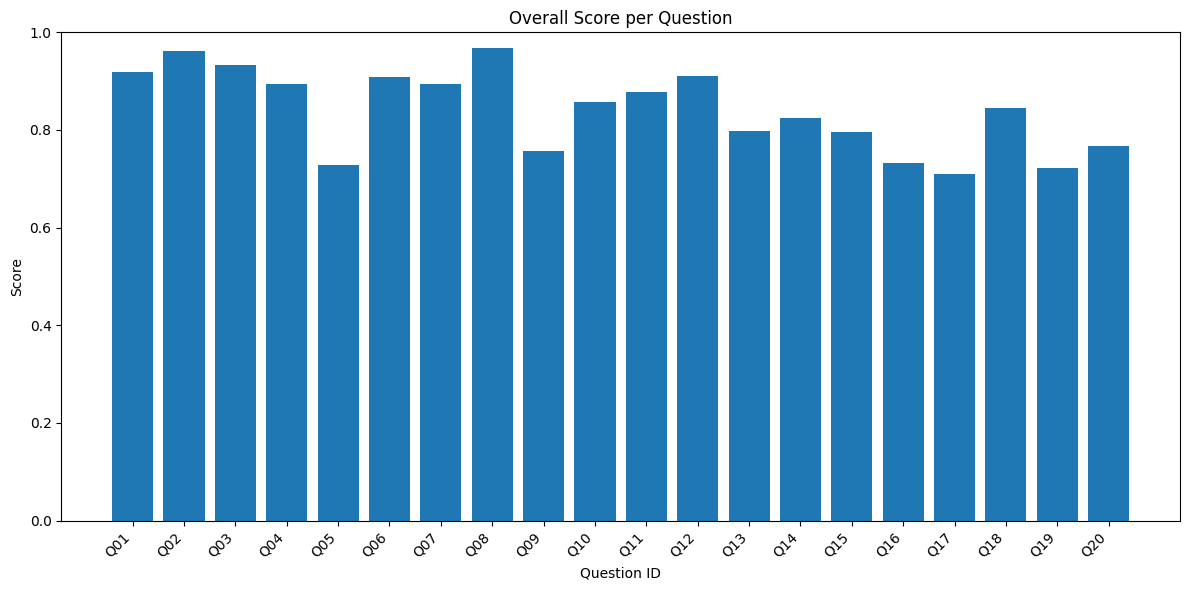

saved /workspace/RAG-LEGAL-LAW-INDONESIA/data/eval_outputs/plots/02_overall_score_distribution.png


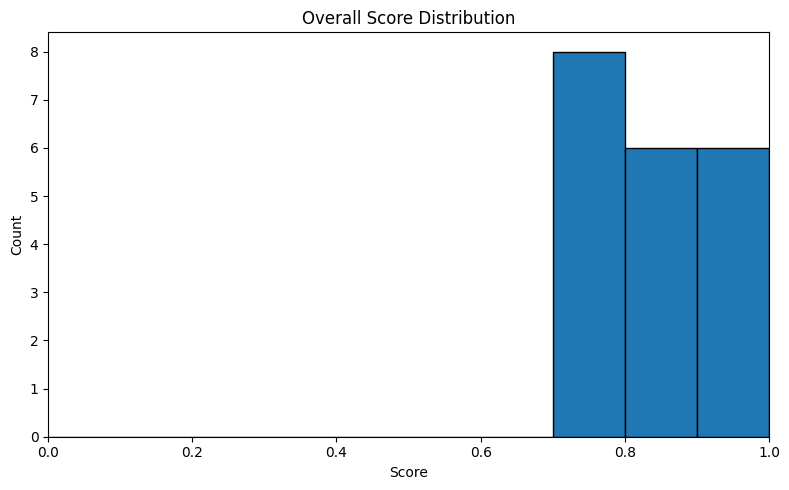

saved /workspace/RAG-LEGAL-LAW-INDONESIA/data/eval_outputs/plots/03_average_metric_scores.png


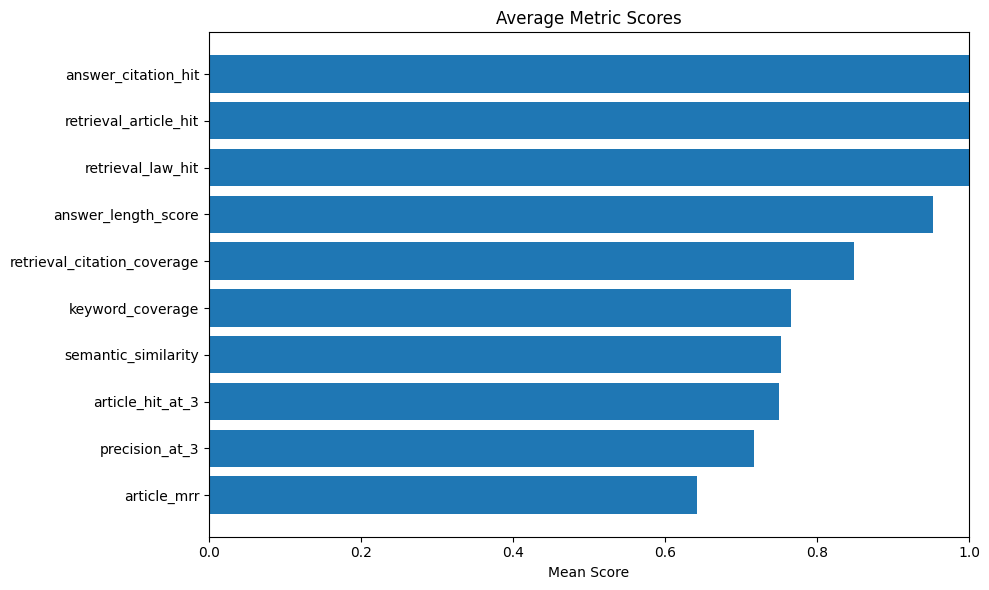

saved /workspace/RAG-LEGAL-LAW-INDONESIA/data/eval_outputs/plots/04_score_by_topic.png


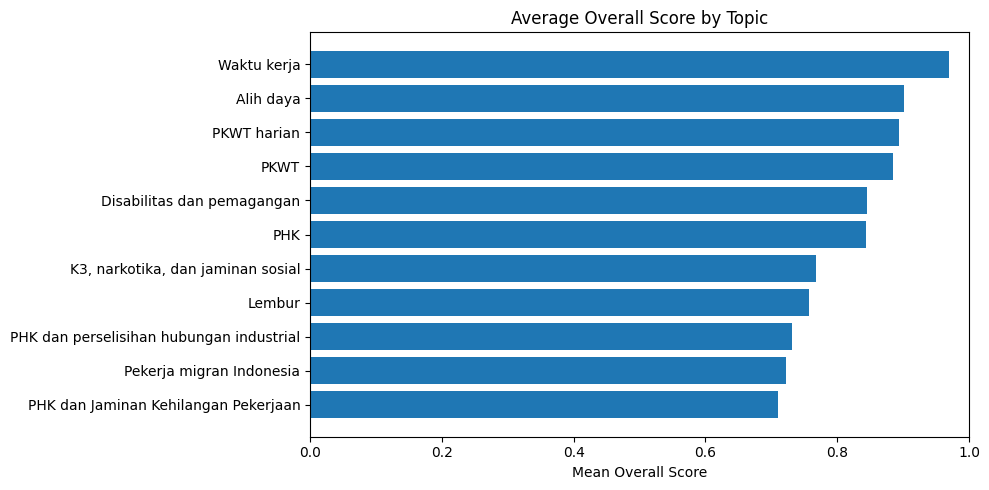

saved /workspace/RAG-LEGAL-LAW-INDONESIA/data/eval_outputs/plots/05_latency_vs_score.png


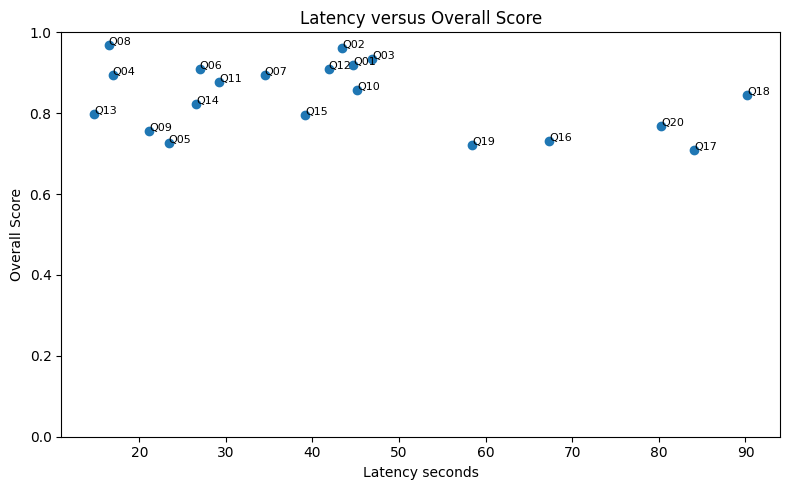

saved /workspace/RAG-LEGAL-LAW-INDONESIA/data/eval_outputs/plots/06_metric_heatmap.png


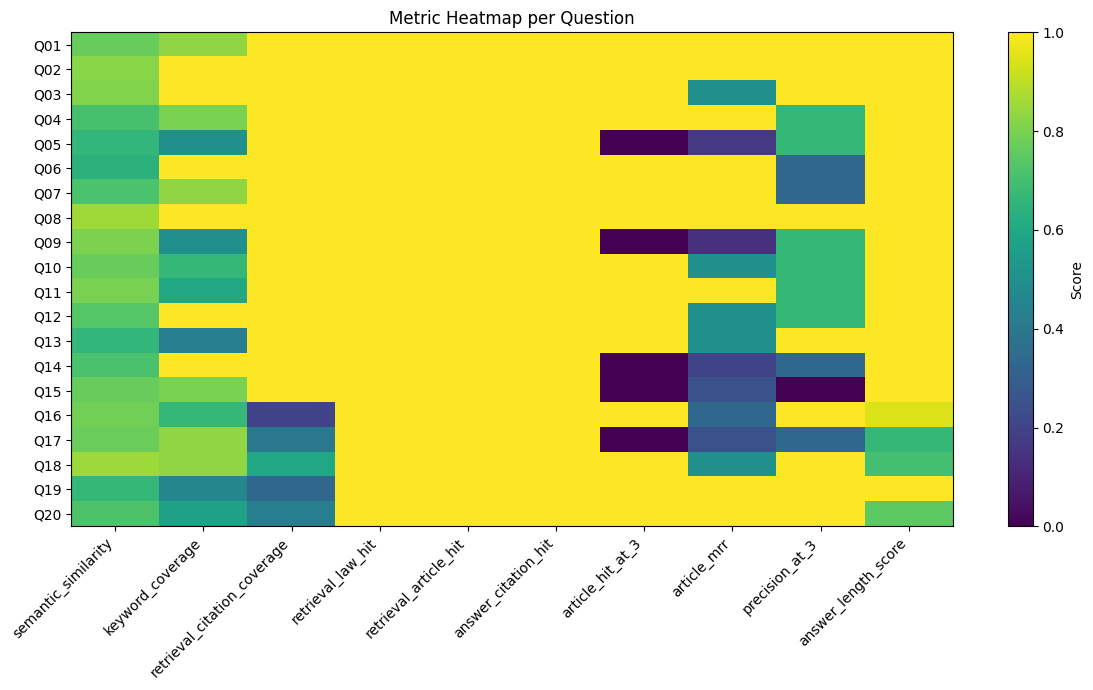

saved /workspace/RAG-LEGAL-LAW-INDONESIA/data/eval_outputs/plots/07_quality_label_count.png


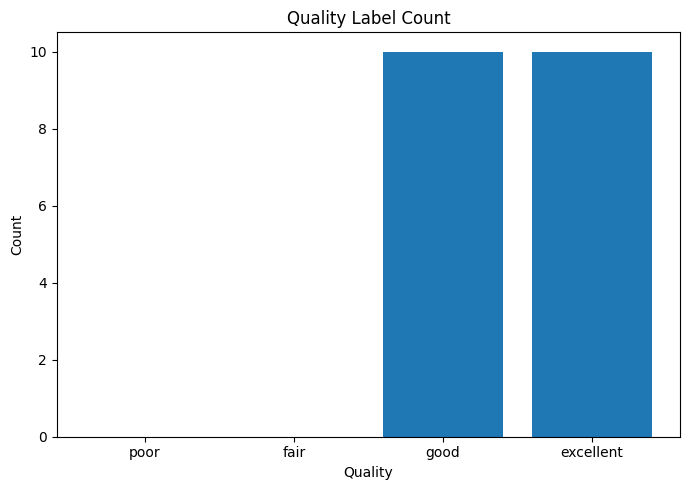

saved /workspace/RAG-LEGAL-LAW-INDONESIA/data/eval_outputs/plots/08_expected_article_rank.png


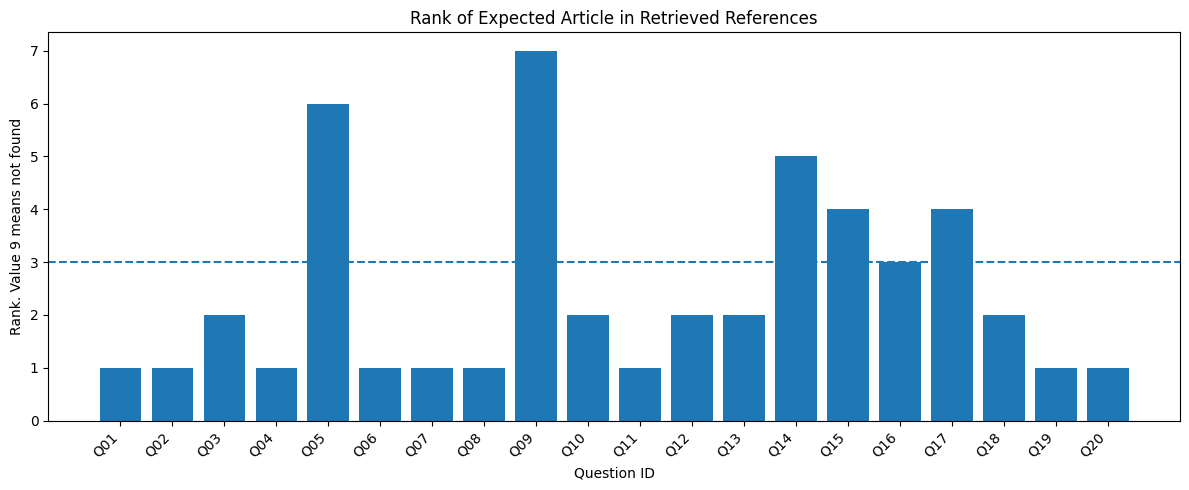

saved /workspace/RAG-LEGAL-LAW-INDONESIA/data/eval_outputs/plots/09_semantic_vs_keyword.png


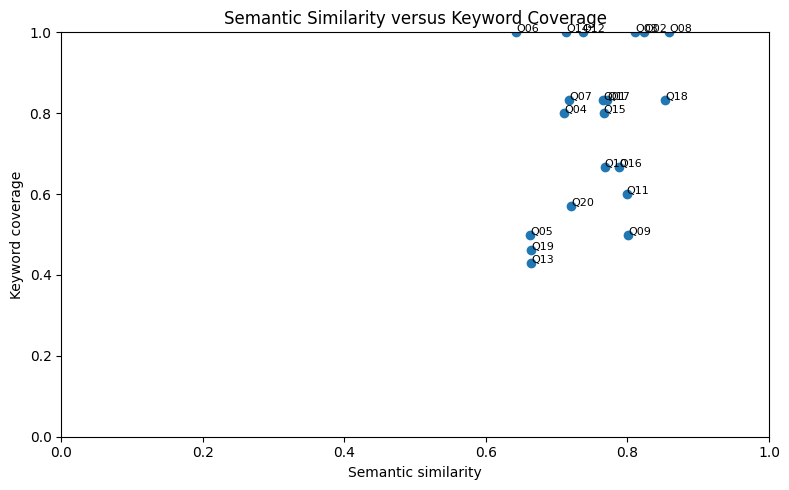

/tmp/ipykernel_4526/2902906088.py:96: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([df.loc[df["topic"] == t, "overall_score"] for t in sorted(df["topic"].dropna().unique())], labels=sorted(df["topic"].dropna().unique()), vert=False)


saved /workspace/RAG-LEGAL-LAW-INDONESIA/data/eval_outputs/plots/10_score_spread_by_topic.png


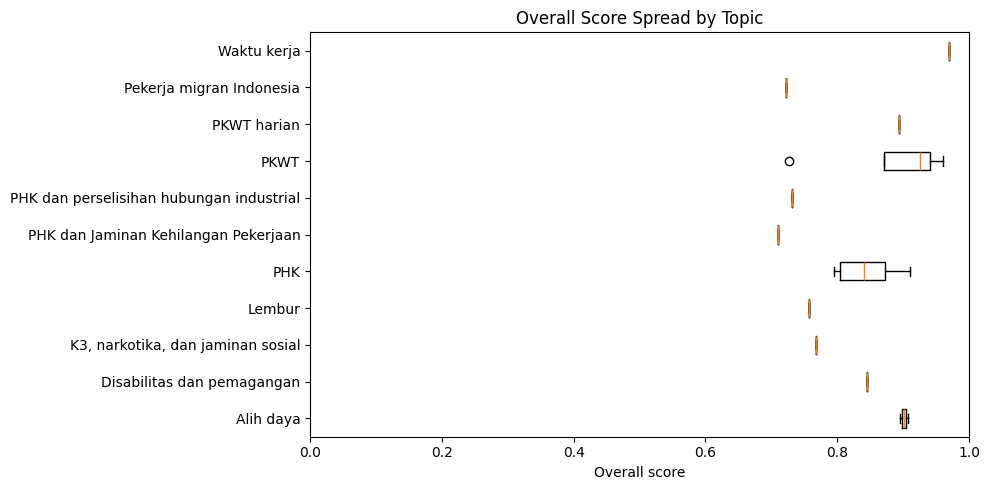

saved /workspace/RAG-LEGAL-LAW-INDONESIA/data/eval_outputs/plots/11_answer_word_count.png


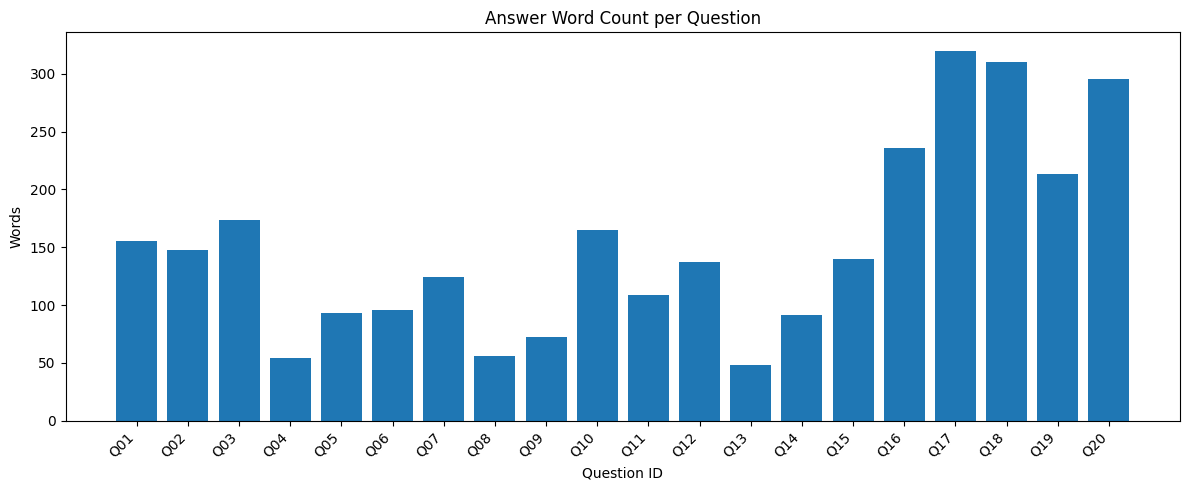

saved /workspace/RAG-LEGAL-LAW-INDONESIA/data/eval_outputs/plots/12_binary_hit_stack.png


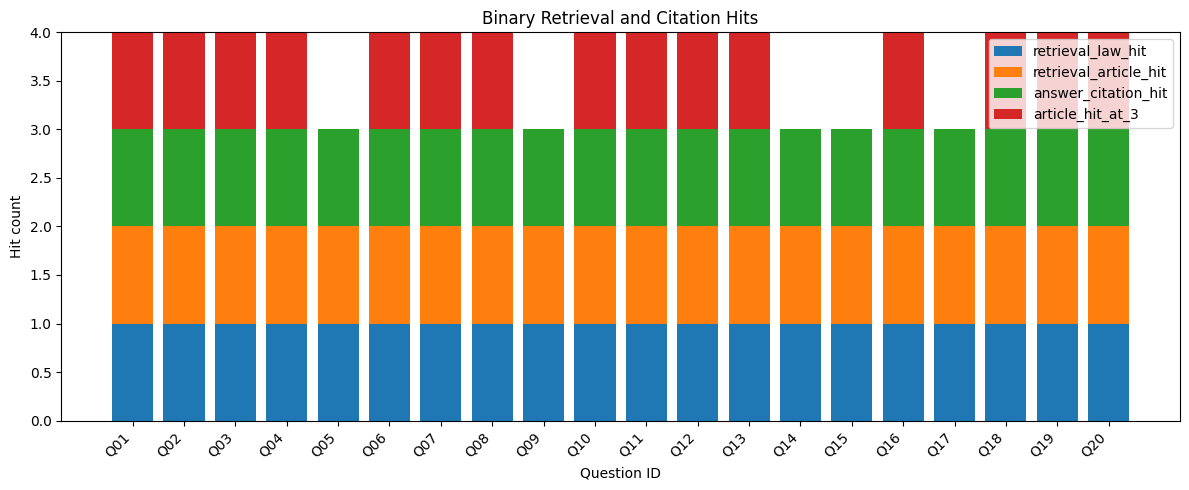

In [12]:
def save_fig(name: str):
    path = PLOT_DIR / name
    plt.tight_layout()
    plt.savefig(path, dpi=200, bbox_inches="tight")
    print("saved", path.resolve())
    plt.show()
    plt.close()

plot_metric_cols = [
    "semantic_similarity", "keyword_coverage", "retrieval_citation_coverage", "retrieval_law_hit", "retrieval_article_hit",
    "answer_citation_hit", "article_hit_at_3", "article_mrr", "precision_at_3", "answer_length_score"
]

plt.figure(figsize=(12, 6))
plt.bar(df["id"].astype(str), df["overall_score"])
plt.ylim(0, 1)
plt.xticks(rotation=45, ha="right")
plt.title("Overall Score per Question")
plt.xlabel("Question ID")
plt.ylabel("Score")
save_fig("01_overall_score_per_question.png")

plt.figure(figsize=(8, 5))
plt.hist(df["overall_score"], bins=np.linspace(0, 1, 11), edgecolor="black")
plt.xlim(0, 1)
plt.title("Overall Score Distribution")
plt.xlabel("Score")
plt.ylabel("Count")
save_fig("02_overall_score_distribution.png")

metric_means = df[plot_metric_cols].mean().sort_values()
plt.figure(figsize=(10, 6))
plt.barh(metric_means.index, metric_means.values)
plt.xlim(0, 1)
plt.title("Average Metric Scores")
plt.xlabel("Mean Score")
save_fig("03_average_metric_scores.png")

plt.figure(figsize=(10, 5))
topic_scores = by_topic.sort_values("overall_score")
plt.barh(topic_scores["topic"].astype(str), topic_scores["overall_score"])
plt.xlim(0, 1)
plt.title("Average Overall Score by Topic")
plt.xlabel("Mean Overall Score")
save_fig("04_score_by_topic.png")

plt.figure(figsize=(8, 5))
plt.scatter(df["latency_seconds"], df["overall_score"])
for _, r in df.iterrows():
    plt.text(r["latency_seconds"], r["overall_score"], str(r["id"]), fontsize=8)
plt.ylim(0, 1)
plt.title("Latency versus Overall Score")
plt.xlabel("Latency seconds")
plt.ylabel("Overall Score")
save_fig("05_latency_vs_score.png")

heat = df.set_index("id")[plot_metric_cols]
plt.figure(figsize=(12, 7))
plt.imshow(heat.values, aspect="auto", vmin=0, vmax=1)
plt.xticks(range(len(plot_metric_cols)), plot_metric_cols, rotation=45, ha="right")
plt.yticks(range(len(heat.index)), heat.index)
plt.colorbar(label="Score")
plt.title("Metric Heatmap per Question")
save_fig("06_metric_heatmap.png")

label_counts = df["quality_label"].value_counts().reindex(["poor", "fair", "good", "excellent"]).fillna(0)
plt.figure(figsize=(7, 5))
plt.bar(label_counts.index.astype(str), label_counts.values)
plt.title("Quality Label Count")
plt.xlabel("Quality")
plt.ylabel("Count")
save_fig("07_quality_label_count.png")

plt.figure(figsize=(12, 5))
rank_values = df["expected_article_rank"].replace(999, np.nan)
plt.bar(df["id"].astype(str), rank_values.fillna(9))
plt.axhline(3, linestyle="--")
plt.xticks(rotation=45, ha="right")
plt.title("Rank of Expected Article in Retrieved References")
plt.xlabel("Question ID")
plt.ylabel("Rank. Value 9 means not found")
save_fig("08_expected_article_rank.png")

plt.figure(figsize=(8, 5))
plt.scatter(df["semantic_similarity"], df["keyword_coverage"])
for _, r in df.iterrows():
    plt.text(r["semantic_similarity"], r["keyword_coverage"], str(r["id"]), fontsize=8)
plt.xlim(0, 1)
plt.ylim(0, 1)
plt.title("Semantic Similarity versus Keyword Coverage")
plt.xlabel("Semantic similarity")
plt.ylabel("Keyword coverage")
save_fig("09_semantic_vs_keyword.png")

plt.figure(figsize=(10, 5))
plt.boxplot([df.loc[df["topic"] == t, "overall_score"] for t in sorted(df["topic"].dropna().unique())], labels=sorted(df["topic"].dropna().unique()), vert=False)
plt.xlim(0, 1)
plt.title("Overall Score Spread by Topic")
plt.xlabel("Overall score")
save_fig("10_score_spread_by_topic.png")

plt.figure(figsize=(12, 5))
plt.bar(df["id"].astype(str), df["answer_word_count"])
plt.xticks(rotation=45, ha="right")
plt.title("Answer Word Count per Question")
plt.xlabel("Question ID")
plt.ylabel("Words")
save_fig("11_answer_word_count.png")

plt.figure(figsize=(12, 5))
bottom = np.zeros(len(df))
for col in ["retrieval_law_hit", "retrieval_article_hit", "answer_citation_hit", "article_hit_at_3"]:
    plt.bar(df["id"].astype(str), df[col], bottom=bottom, label=col)
    bottom += df[col].values
plt.xticks(rotation=45, ha="right")
plt.ylim(0, 4)
plt.title("Binary Retrieval and Citation Hits")
plt.xlabel("Question ID")
plt.ylabel("Hit count")
plt.legend()
save_fig("12_binary_hit_stack.png")

In [13]:
worst = failure_review.head(5)
report = f"""# Laporan Evaluasi RAG

Jumlah soal: {len(df)}
Model: {MODEL_ID}

## Ringkasan

- Rata-rata overall score: {df['overall_score'].mean():.3f}
- Median overall score: {df['overall_score'].median():.3f}
- Rata-rata semantic similarity: {df['semantic_similarity'].mean():.3f}
- Keyword coverage: {df['keyword_coverage'].mean():.3f}
- Retrieval citation coverage: {df['retrieval_citation_coverage'].mean():.3f}
- Retrieval citation hit rate: {df['retrieval_citation_hit'].mean():.3f}
- Retrieval law hit rate: {df['retrieval_law_hit'].mean():.3f}
- Retrieval article hit rate: {df['retrieval_article_hit'].mean():.3f}
- Article hit@3: {df['article_hit_at_3'].mean():.3f}
- Article MRR: {df['article_mrr'].mean():.3f}
- Precision@3: {df['precision_at_3'].mean():.3f}
- Answer citation hit rate: {df['answer_citation_hit'].mean():.3f}
- Rata-rata latency detik: {df['latency_seconds'].mean():.2f}

## Lima Skor Terendah

{worst[['id', 'topic', 'overall_score', 'keyword_missing', 'expected_article_rank', 'top1_reference']].to_markdown(index=False)}

## File Penting

1. ../data/eval_outputs/rag_inference_results.csv
2. ../data/eval_outputs/evaluation_table.csv
3. ../data/eval_outputs/evaluation_summary.csv
4. ../data/eval_outputs/evaluation_by_topic.csv
5. ../data/eval_outputs/failure_review.csv
6. ../data/eval_outputs/evaluation_report.xlsx
7. ../data/eval_outputs/plots
"""
report_path = OUTPUT_DIR / "evaluation_report.md"
report_path.write_text(report, encoding="utf-8")
print(report)
print("saved", report_path.resolve())

# Laporan Evaluasi RAG

Jumlah soal: 20
Model: Qwen/Qwen3.5-9B

## Ringkasan

- Rata-rata overall score: 0.840
- Median overall score: 0.852
- Rata-rata semantic similarity: 0.752
- Keyword coverage: 0.766
- Retrieval citation coverage: 0.848
- Retrieval citation hit rate: 1.000
- Retrieval law hit rate: 1.000
- Retrieval article hit rate: 1.000
- Article hit@3: 0.750
- Article MRR: 0.642
- Precision@3: 0.717
- Answer citation hit rate: 1.000
- Rata-rata latency detik: 42.57

## Lima Skor Terendah

| id   | topic                                    |   overall_score | keyword_missing                                                                                                                     |   expected_article_rank | top1_reference                                                                         |
|:-----|:-----------------------------------------|----------------:|:-----------------------------------------------------------------------------------------------------------